# Healthy SHR Prediction Example

This notebook demonstrates a **single healthy-condition scapulohumeral rhythm (SHR) prediction** using the calibrated parameter set for participant `par2`.

This simulation corresponds to the `Fig.5`,`Fig.6` and`Fig.7` (Healthy condition) in the paper.

The optimization problem is formulated as a direct collocation problem solved with `opty.Problem`. We solve for states and controls that satisfy implicit dynamics while minimizing a weighted objective:

$$
J = J_{traj} + J_{act} + J_{GH\_stab} + J_{smooth\_u} + J_{smooth\_f} + J_{smooth\_exc}
$$

where each term is generated by helper functions in `equations.py`, mainly:

- `objective_traj_quat(...)`
- `objective_min_activation(...)`
- `objective_max_GH_stab(...)`
- `objective_state_diff(...)`

The code cells below first build dynamics and muscle terms, then assemble the objective and constraints, solve, and export results (`.mat`, `.mot`).

In [22]:
from opty import Problem, create_objective_function, parse_free
import sympy as sp
import numpy as np
import scipy as sc
import time as tm
import pickle
import sympy.physics.mechanics as me
import sys
sys.path.insert(0, "..")
from importlib import reload
import matplotlib.pyplot as plt
import equations as eq
import trajectory_lib as tr

participant = 'par2'
GH_seq = 'YZY' # Used for .mot file generation. The OpenSim model is built with YZY sequence for GH joint.

# This OS_model contains all information about the model together with the muscle polynomial coefficients of the muscle-tendon path approximations.
OS_struct = sc.io.loadmat('../Motions/'+participant+'/OS_model_prediction.mat')

wGH = 2 # weight for GH stability term
RC_lim = 1.0 # we use 100% of the supra and infra muscles capacity

# Define inclination (around z-axis) and version (around y-axis) angles of the glenoid.
tilt_y = 13
tilt_z = -6.5

w_traj = 200
simulation = 'All_elevations'
w_diff_vel = 1e-2
w_diff_exc = 1e-3
w_diff_faux = 1e-2
w_act = 1
thor_hum_only = True
clav_x_pos = 0.4

## 1) Model Setup And Implicit Dynamics

This section loads the OpenSim-derived model struct and builds the quaternion-based equations of motion with reaction-force states at the GH joint using:

- `create_eoms_quat_w_RF(OS_struct, ...)`

Returned symbols are interpreted as:

- `q`: generalized coordinates (joint kinematics)
- `u`: generalized speeds
- `faux`: GH reaction forces variables. Scaled by 800 in the EoMs creation so the variables are close to 1.
- `fr + frstar = 0`: implicit dynamic equations of motion, the last 3 elements are implicitly defined GH reaction forces with 3 reaction forces as decision variables 
- `kinematical`: kinematic differential constraints

In [23]:
# build equations of motion, details are in muscle parameter calibration notebook
q,u,faux,fr,frstar,kinematical = eq.create_eoms_quat_w_RF(OS_struct,hand_weight = 0,derive = 'numeric',gen_matlab_functions = 0)
print('Equations of motion created')

Equations of motion created


In [24]:
# coordinates and speeds
print(q)
print(u)

[q0_clavicula(t), q1_clavicula(t), q2_clavicula(t), q3_clavicula(t), q0_scapula(t), q1_scapula(t), q2_scapula(t), q3_scapula(t), q0_humerus(t), q1_humerus(t), q2_humerus(t), q3_humerus(t), q_ulna(t)]
[w1_clavicula(t), w2_clavicula(t), w3_clavicula(t), w1_scapula(t), w2_scapula(t), w3_scapula(t), w1_humerus(t), w2_humerus(t), w3_humerus(t), w_ulna(t)]


In [25]:
# first 10 elements of fr+frstar are the equations of motion
# the last 3 elements are implicitly defined GH reaction forces from dynamics
# do not print the full fr+frstar because it is very long and would crash the notebook
len(fr+frstar)

13

## 2) Muscle Forces and activation dynamics

This section assembles the full impicit system.

### Muscle and passive terms

Using `polynomials_quat(...)`, we compute:

- `TE`: muscle-generated generalized torques (10x1)
- `activations`: me.dynamicsymbols of the activation states
- `TE_conoid`: conoid ligament torque contribution (10x1 to be consistent with EoMs shape but contributes to AC joint only)
- `GH_mus_forces`: GH muscle reaction-force components (3x1 - x,y,z elements)

Activation dynamics are added via `act_dynamics(...)` for each muscle, introducing excitations as controls.

In [26]:
# We use the calibrated params saved in matlab struct
calibrated_params = sc.io.loadmat('../Motions/'+participant+'/calibrated_params.mat')

# Build the torque from muscle forces, conoid ligament and x,y,z forces at GH joint.
TE,activations,TE_conoid, _,_,_,_,_, GH_mus_forces = eq.polynomials_quat(OS_struct,q,u,calibrated_params = calibrated_params, derive = 'numeric',RC_lim = RC_lim)

include_activation_dynamics = True

# Merge the EoMs with muscle forces, conoid ligament force and GH muscle forces.
eoms_implicit = sp.Matrix(kinematical).col_join(fr+frstar+sp.Matrix([TE+sp.Matrix(TE_conoid)]).col_join(GH_mus_forces))

if include_activation_dynamics:
    excitations = []
    act_ode = []
    for i in range(len(activations)):
        excitations.append(me.dynamicsymbols('exc'+str(activations[i])[3:-3]))
        current_mus_ind = int(str(activations[i])[4:-3])
        current_mus = OS_struct['model']['muscles'].item()[0,(current_mus_ind-1)]
        t_act = current_mus['tact'][0,0].item()
        t_deact = current_mus['tdeact'][0,0].item()
        act_ode.append(activations[i].diff() - eq.act_dynamics(activations[i],excitations[i],t_act,t_deact))
    sp_act_ode = sp.Matrix(act_ode)
    eoms_implicit = eoms_implicit.col_join(sp_act_ode)

### 2.1 Data Tracking Targets And Objective Components

This block loads trajectory, defines optimization state/control vectors, and instantiates objective terms from `equations.py`.

#### Objective design (from `equations.py`)

- `objective_traj_quat(...)`: tracks humerus trajectory, it includes the soft constraint for unit quaternions
- `objective_min_activation(...)`: penalizes muscular effort.
- `objective_max_GH_stab(...)`: penalizes GH shear relative to compression in the glenoid coordinate frame.
- `objective_state_diff(...)`: smoothness penalty for speeds, GH reaction-force states, and excitations.

In [27]:
interval_value = 0.04

# Path to the experimental trajectory.
file = '../Motions/' + participant + '/' + simulation + '/' + simulation
traj_original, omega, num_nodes, time = tr.exp_trajectory_quat(file,interval_value)

# Get the SC rotation in t = 0
qSC0_t0 = traj_original[:,0][:4]

# Convert the original trajectory defined in joints to orientations with respect to thorax frame for scapula and humerus. Exclude axial rotation of clavicle. Rotation in elbow is kept the same as in the original trajectory.
traj = tr.exp_trajectory_quat_myobj(traj_original,clav_x_pos)

# Indexes_emg is used to define the nodes where EMG is not defined (the artificially added pauses).
emg, indexes_emg = tr.exp_emg('../Motions/'+participant+'/'+simulation+'/EMG_'+participant+'_'+simulation+'.mat', num_nodes = num_nodes)

# We exclude clavicle and scapula from the trajectory tracking objective.
index_clav_scap = 0
# Humerus tracking is off during the pauses to let humerus find stable neutral position.
# len(indexes_emg) = num_nodes
index_hum = indexes_emg

# All states (state_symbols) and inputs (specified_symbols).
if include_activation_dynamics:
    state_symbols = tuple(q+u+faux+activations)
    specified_symbols = tuple(excitations)
else:
    state_symbols = tuple(q+u+faux)
    specified_symbols = tuple(activations)

num_states = len(state_symbols) 
num_q = len(q)
num_u = len(u)
num_faux = len(faux)
num_inputs = len(specified_symbols)
t = me.dynamicsymbols._t

# Build objective functions and their Jacobians.
objective_traj,objective_traj_jac, objective_SC_t0, objective_SC_t0_jac = eq.objective_traj_quat(num_q,interval_value,clav_x_pos,True)
objective_act,objective_act_jac = eq.objective_min_activation(activations,interval_value)
objective_exc,objective_exc_jac = eq.objective_min_activation(activations,interval_value)
objective_maxstab, objective_maxstab_jac = eq.objective_max_GH_stab(tilt_y=tilt_y,tilt_z=tilt_z,interval_value = interval_value)
obj_min_diff,obj_min_diff_jac = eq.objective_state_diff(num_nodes,interval_value)

### 2.2 Objective And Gradient Definitions

This block defines the callable objective and analytical gradient passed to `opty.Problem`.

In [28]:
# Build callable objective and gradient functions for the optimizer.
def obj(free):
    min_traj = w_traj * np.sum(objective_traj(np.split(free[:num_q*num_nodes],num_q),traj,index_clav_scap,index_hum))
    min_SC_t0 = w_traj * np.sum(objective_SC_t0(free[0::num_nodes][:4],qSC0_t0))
    min_SC_tf = w_traj * np.sum(objective_SC_t0(free[num_nodes-1::num_nodes][:4],qSC0_t0))

    min_vel_dif = w_diff_vel * np.sum((obj_min_diff(np.transpose(np.split(free[num_q*num_nodes:(num_q + num_u)*num_nodes],num_u)))))
    min_faux_dif = w_diff_faux * np.sum((obj_min_diff(np.transpose(np.split(free[(num_q+num_u)*num_nodes:(num_q + num_u+num_faux)*num_nodes],num_faux)))))

    min_act = w_act * np.sum(objective_act(np.split(free[(num_q + num_u + num_faux)*num_nodes:(num_q + num_u + num_faux + num_inputs)*num_nodes],num_inputs)))

    min_instab = wGH * np.sum(objective_maxstab(np.split(free[(num_q + num_u)*num_nodes:(num_q + num_u + num_faux)*num_nodes],3)))

    obj = (min_traj + min_vel_dif + min_act + min_instab + min_faux_dif + min_SC_t0 + min_SC_tf) #
    if include_activation_dynamics:
        min_exc_dif = w_diff_exc * np.sum((obj_min_diff(np.transpose(np.split(free[(num_states)*num_nodes:(num_states + num_inputs)*num_nodes],num_inputs)))))
        obj += (min_exc_dif)

    return obj.item()

def obj_grad(free):
    grad = np.zeros_like(free)
    grad[:num_q*num_nodes] += w_traj * np.concatenate(objective_traj_jac(np.split(free[:num_q*num_nodes],num_q),traj,index_clav_scap,index_hum))
    grad[0::num_nodes][:4] += w_traj * np.sum(objective_SC_t0_jac(free[0::num_nodes][:4],qSC0_t0))
    grad[num_nodes-1::num_nodes][:4] += w_traj * np.sum(objective_SC_t0_jac(free[num_nodes-1::num_nodes][:4],qSC0_t0))

    grad[(num_q + num_u + num_faux)*num_nodes:(num_q + num_u + num_faux + num_inputs)*num_nodes] += w_act * np.concatenate(objective_act_jac(np.split(free[(num_q + num_u + num_faux)*num_nodes:(num_q + num_u + num_faux + num_inputs)*num_nodes],num_inputs)))

    grad[num_q*num_nodes:(num_q + num_u)*num_nodes] += w_diff_vel * np.concatenate(np.transpose((obj_min_diff_jac(np.transpose(np.split(free[num_q*num_nodes:(num_q + num_u)*num_nodes],num_u)))[0,:,:])))
    grad[(num_q+num_u)*num_nodes:(num_q + num_u+num_faux)*num_nodes] += w_diff_faux * np.concatenate(np.transpose((obj_min_diff_jac(np.transpose(np.split(free[(num_q+num_u)*num_nodes:(num_q + num_u+num_faux)*num_nodes],num_faux)))[0,:,:])))
    grad[(num_q + num_u)*num_nodes:(num_q + num_u + num_faux)*num_nodes] += wGH * np.concatenate(objective_maxstab_jac(np.split(free[(num_q + num_u)*num_nodes:(num_q + num_u + num_faux)*num_nodes],3)))

    if include_activation_dynamics:
        grad[(num_states)*num_nodes:(num_states + num_inputs)*num_nodes] += w_diff_exc * np.concatenate(np.transpose((obj_min_diff_jac(np.transpose(np.split(free[(num_states)*num_nodes:(num_states + num_inputs)*num_nodes],num_inputs)))[0,:,:])))

    return grad

# Input values to check the objective and gradient functions before solving the optimization problem.
print('obj_check', obj(np.ones(num_states*num_nodes + num_inputs*num_nodes)*0.01))
print('obj_grad_check', sum(obj_grad(np.ones(num_states*num_nodes + num_inputs*num_nodes)*0.01)))

obj_check 6633.649768277807
obj_grad_check -1942.6387237663143


## 2.3 Constraints, Bounds, Solve, And Export

### Constraints and bounds

- unit-quaternion constraints at the initial node
- zero-speed boundary constraints at initial/final nodes
- physiological bounds for activations/excitations
- coordinate bounds around experimental trajectory
- compressive GH-force x-element (`faux[0] < 0`)

These choices keep the solution physiologically plausible while maintaining numerical stability.

This block applies physical constraints and bounds, solves the NLP, and writes `.mat` and `.mot` outputs.

In [29]:
instance_constraints = []

# Velocities are set zero at the first and last node.
for i in range(num_u):
    instance_constraints.append(u[i].func(time[-1]))
    instance_constraints.append(u[i].func(time[0]))

# Set the hard constraint of unit quaternion in the first node.
instance_constraints.append(state_symbols[0].func(0)**2 + state_symbols[1].func(0)**2 + state_symbols[2].func(0)**2 + state_symbols[3].func(0)**2 - 1) # SC
instance_constraints.append(state_symbols[4].func(0)**2 + state_symbols[5].func(0)**2 + state_symbols[6].func(0)**2 + state_symbols[7].func(0)**2 - 1) # AC
instance_constraints.append(state_symbols[8].func(0)**2 + state_symbols[9].func(0)**2 + state_symbols[10].func(0)**2 + state_symbols[11].func(0)**2 - 1) # GH

# Bounds for activations and excitations.
bounds1 = (0.0,1.0)
bounds = (bounds1,)*len(activations)
bndrs = dict(zip(activations,bounds))
if include_activation_dynamics:
    bndrs_exc = dict(zip(excitations,(bounds1,)*len(excitations)))
    bndrs.update(bndrs_exc)

for iact in activations:
    bndrs.update({iact: (0.0, 1.0)})

# Set bounds for the coordinates +- 0.2 around the original trajectory. 
# The upper bound for the scalar part of the quaternion is set to 1 because it cannot be higher than 1.
for i in range(num_q):
    if i == 0 or i == 4 or i == 8:
        bndrs.update({q[i]: (min(traj_original[i,:])-0.2, 1.0)})
    else:
        bndrs.update({q[i]: (min(traj_original[i,:])-0.2, max(traj_original[i,:])+0.2)})

# Set bounds for the compressive forces at GH joint to be negative (compressive).
bndrs.update({faux[0]: (-2,0)})

start = tm.time()
# Build the problem. This takes around 25 minutes on 13th Gen Inter(R) Core(TM) i5-13400F in WSL2 using clang compiler.
# It calculates analytic jacobians and compiles the problem to cython. 
prob = Problem(obj, obj_grad, eoms_implicit, state_symbols,
            num_nodes, interval_value,
            known_parameter_map={},
            instance_constraints=instance_constraints,
            bounds=bndrs,
            integration_method='midpoint',
            parallel = False)

time_to_create = tm.time() - start
print('Time to build the problem: ', time_to_create)

# Apart from these two options, we use the default settings of the solver.
prob.add_option('limited_memory_max_history', 40)
prob.add_option('max_iter',2000)

# We use the result from the calibration as the initial guess.
initial_guess = tr.initial_guess_from_solution('../Motions/'+participant+'/'+simulation+'/All_elevations_params_calibration.mat',prob.num_free)[:prob.num_free]

# Solve the problem. This takes around 1 hour.
time_2_solve_start = tm.time()
solution, info = prob.solve(initial_guess)
time_2_solve = tm.time() - time_2_solve_start
print('Time to solve the problem: ', time_2_solve)
print(info['status_msg'])
print(info['obj_val'])
act_obj = np.sum(solution[num_states*num_nodes:(num_states + num_inputs)*num_nodes]**2)
objective_value = prob.obj_value
print('Objective activations: ', act_obj)

# Save to matlab struct. The name is hardcoded to correspond to the result from the sensitivity analysis.
file_name = '../Motions/'+participant+'/'+simulation+'/res_SHR_0.mat'
tr.sol2struct(solution,activations,num_q,num_u,num_faux,num_inputs,num_nodes,time,objective_value,time_2_solve,file_name,include_activation_dynamics)
# Save to .mot file.
file_name_mot = '../Motions/'+participant+'/'+simulation+'/res_SHR_0.mot'
tr.sol2mot_quat(solution, num_nodes, len(q), time, file_name_mot, GH_seq)

Time to build the problem:  1505.6845633983612
This is Ipopt version 3.14.16, running with linear solver MUMPS 5.7.3.

Number of nonzeros in equality constraint Jacobian...: 22876592
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:    75040
                     variables with only lower bounds:        0
                variables with lower and upper bounds:    71824
                     variables with only upper bounds:        0
Total number of equality constraints.................:    40874
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  5.9338793e+00 2.20e+02 3

## 3) Outputs

After successful convergence, this notebook writes:

- `res_SHR_0.mat`: full optimization result structure (states, inputs, objective, timing).
- `res_SHR_0.mot`: kinematic trajectory exported for OpenSim visualization.

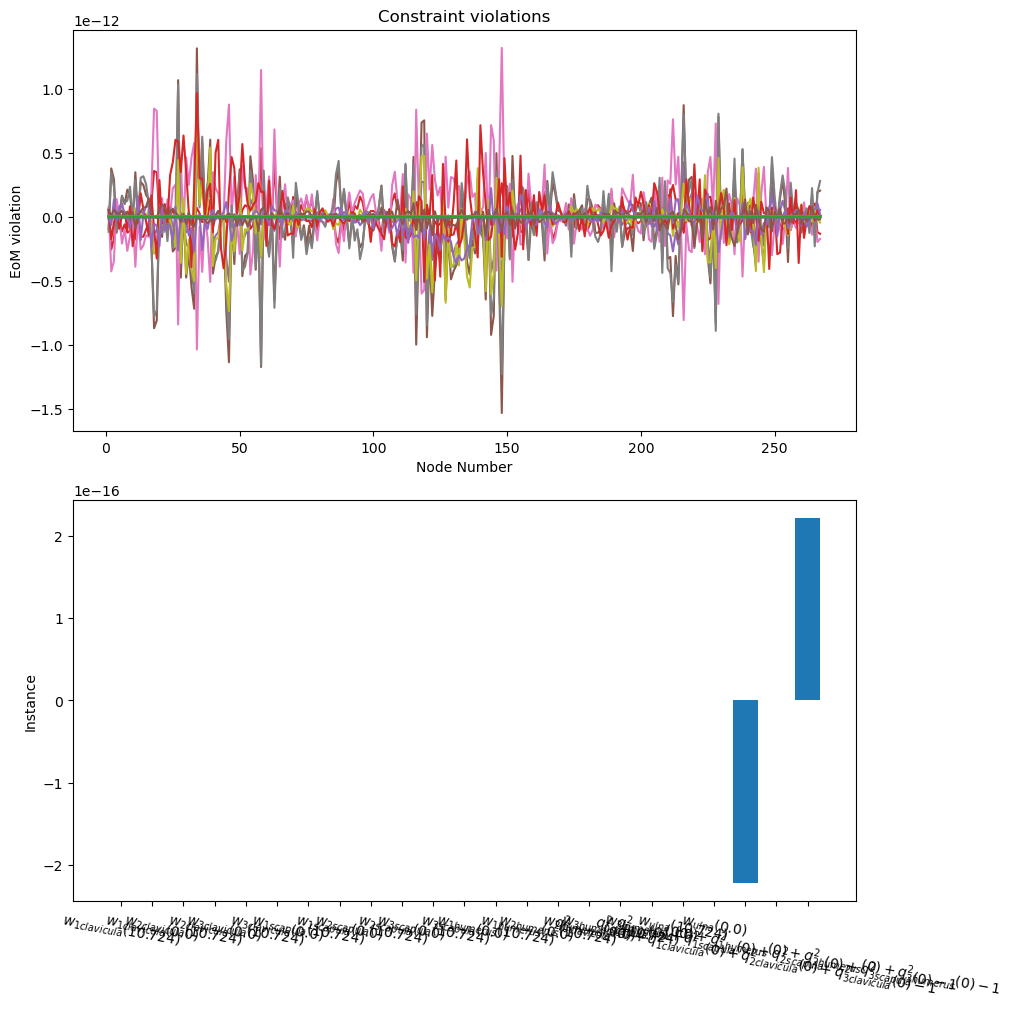

In [31]:
# Plot constraint violations.
fig, axes = plt.subplots(2, 1, figsize=(10, 10),
                         layout='constrained')
_ = prob.plot_constraint_violations(solution, axes=axes)